In [1]:
from mushroom_rl.environments import LQR
from mushroom_rl.solvers.lqr import *
import jax
import jax.numpy as jnp
jax.config.update('jax_default_matmul_precision', 'float32')

STATE_DIM,A_DIM = 4,2
env = LQR.generate(s_dim=STATE_DIM,a_dim=A_DIM,gamma=0.995,episodic=True,horizon=1000,random_init=True)

/home/mahdi/Desktop/supersac/.venv/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn


In [2]:
def evaluate_critic(agent,test_transitions):
    
    
    K = np.array(agent.actor.params['means']['kernel'])
    noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without
    
    Q_true = []
    
    for obs,action in zip(test_transitions["observations"],test_transitions["actions"]):
        
        Q_true.append(compute_lqr_Q_gaussian_policy(obs,action,env,-K.T,noise))
    
    Q_true = jnp.array(Q_true)
    
    Q = agent.critic(test_transitions["observations"],test_transitions["actions"]).mean(axis=0)
    
    return jnp.sqrt((Q-Q_true)**2).mean(), (Q-Q_true).mean()

def compute_gradient(agent,transitions):

    K = np.array(agent.actor.params['means']['kernel'])
    noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without

    grad = np.zeros((1,np.size(K)))

    for obs,action,discount in zip(transitions["observations"],transitions["actions"],transitions["discounts"]):
        
        grad+= discount * compute_lqr_Q_gaussian_policy_gradient_K(obs,action,env,-K.T,noise)

    grad = grad/(transitions["discounts"].sum())
    
    return grad
        
    
    

In [3]:

import os
import wandb
import argparse
import itertools
import numpy as np
import jax
import jax.numpy as jnp
from jaxrl_m.common import CodeTimer
import logging
import envpool
from flax.core.frozen_dict import unfreeze
logging.basicConfig(level=logging.CRITICAL)


def get_batch(i,batches):
    return  jax.tree.map(lambda x: x[i], batches)

def body(i,val):
    agent,batches = val
    return (agent.update_critics(get_batch(i,batches)),batches)

def str2bool(v):
    if isinstance(v, bool):
        return v
    if v.lower() in ('yes', 'true', 't', 'y', '1'):
        return True
    elif v.lower() in ('no', 'false', 'f', 'n', '0'):
        return False
    else:
        raise argparse.ArgumentTypeError('Boolean value expected.')
    

def none_or_str(value):
    if value == 'None':
        return None
    return value

# Set env variables
os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
os.environ['PYTHONHASHSEED'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

##############################
parser = argparse.ArgumentParser()

parser.add_argument('--seed',type=int,default=42) 

parser.add_argument('--algo_name', type=str, default='superppo', help='the name of the RL algorithm')
parser.add_argument('--project_name',type=str,default="gradient_exps") 

parser.add_argument('--env_name',type=str,default="Hopper-v5") 
parser.add_argument('--max_steps',type=int,default=500_000) 
parser.add_argument('--max_episode_steps',type=int,default=1000) 
parser.add_argument('--num_rollouts',type=int,default=4) 
parser.add_argument('--gamma',type=float,default=0.995)
parser.add_argument('--healthy_reward',type=float,default=1.) 
parser.add_argument('--entropy_coeff',type=float,default=1.) 

parser.add_argument('--discount_actor',type=str2bool,default=True)
parser.add_argument('--min_target',type=str2bool,default=False)
parser.add_argument('--discount_entropy',type=str2bool,default=True) 
parser.add_argument('--on_policy_data',type=str2bool,default=False)
parser.add_argument('--adaptive_critics',type=str2bool,default=False) 
parser.add_argument('--num_critics',type=int,default=2)

parser.add_argument('--critic_lr',type=float,default=3e-4) 
parser.add_argument('--actor_lr',type=float,default=3e-4) 
parser.add_argument('--temperature',type=float,default=0.)
parser.add_argument('--use_layer_norm',type=str2bool,default=True)

parser.add_argument('--momentum',type=float,default=0.) 
parser.add_argument('--num_actor_updates',type=int,default=5) 
parser.add_argument('--clipping_ratio',type=float,default=0.1) 
parser.add_argument('--hidden_dims',type=int,default=64) 
parser.add_argument('--episode_based',type=str2bool,default=False) 
parser.add_argument('--tanh_squash_actions',type=str2bool,default=True) 


args = parser.parse_args(args=[])



from jaxrl_m.onsac_clean import *

hidden_dims = ()
NUM_UPDATES = 1000
data = []

import os
from functools import partial
import numpy as np
import jax
import tqdm
import gymnasium as gym


from jaxrl_m.wandb import setup_wandb, default_wandb_config, get_flag_dict
import wandb
from jaxrl_m.evaluation import supply_rng, evaluate, flatten, EpisodeMonitor
from jaxrl_m.dataset import ReplayBuffer,ActorReplayBuffer
from collections import deque
from jax import config
from jaxrl_m.utils import flatten_rollouts
from jaxrl_m.evaluate_critic import evaluate_many_critics
from jaxrl_m.rollout import rollout_policy_lqr
from jax import config
import copy 


config.update("jax_debug_nans", True)

wandb_config = {
    'project': args.project_name,
    'name':None,
    'hyperparam_dict':args.__dict__,
    }
wandb_run = setup_wandb(**wandb_config)

eval_episodes=10
batch_size = 256
max_steps = args.max_steps
start_steps = 0
log_interval = 10000
n_grads = 0


observation = jnp.ones(env._mdp_info.observation_space.shape)
action = jnp.ones(env._mdp_info.action_space.shape)


example_transition = dict(
    observations=observation,
    actions=action,
    rewards=0.0,
    masks=1.0,
    next_observations=observation,
    pre_actions = action,
    discounts=1.0,
    log_probs=0.,
)
buffer_size = args.num_rollouts*args.max_episode_steps if args.on_policy_data else 100_000
replay_buffer = ReplayBuffer.create(example_transition, size=int(buffer_size))
actor_buffer = ActorReplayBuffer.create(example_transition, size=int(args.num_rollouts*args.max_episode_steps))
test_buffer = ActorReplayBuffer.create(example_transition, size=int(args.num_rollouts*args.max_episode_steps))



args_dict = {

"seed": args.seed,
"observations":example_transition['observations'][None],
"actions":example_transition['actions'][None],
"max_steps":max_steps,
"discount":args.gamma,
"discount_actor":args.discount_actor,
"min_target":args.min_target,
"discount_entropy":args.discount_entropy,
"adaptive_critics":args.adaptive_critics,
"num_critics": args.num_critics,
"entropy_coeff":args.entropy_coeff,
"temperature":args.temperature,
"actor_lr":args.actor_lr,
"critic_lr":args.critic_lr,
"momentum":args.momentum,
"clipping_ratio":args.clipping_ratio,
"num_actor_updates":args.num_actor_updates,
"critic_hidden_dims":(args.hidden_dims,args.hidden_dims),
"actor_hidden_dims":(),
"use_layer_norm": args.use_layer_norm,
"state_dependent_std":False,
"tanh_squash_distribution":False,
"tanh_squash_actions":False,
"use_bias":False,

}

args_dict_min = copy.deepcopy(args_dict)
args_dict_min["min_target"]=True
agent = create_learner(**args_dict)
agent = agent.replace(config=unfreeze(agent.config))
agent_on = create_learner(**args_dict)
agent_min = create_learner(**args_dict_min)

##############




exploration_metrics = dict()
#obs,info = env.reset()    
exploration_rng = jax.random.PRNGKey(0)
i = 0
unlogged_steps,cached_steps = 0,0
policy_rollouts = deque([], maxlen=20)
warmup = True
R2,bias = jnp.ones(args.num_critics),jnp.zeros(args.num_critics)



with tqdm.tqdm(total=max_steps) as pbar:
    
    while (i < max_steps):
        with jax.log_compiles(False):
            warmup=(i < start_steps)
            
            logging.debug('policy rollout')
            replay_buffer,actor_buffer,policy_rollout,policy_return,variance,undisc_policy_return,num_steps = rollout_policy_lqr(
                                                                    agent,env,exploration_rng,
                                                                    replay_buffer,actor_buffer,eval=False,
                                                                    num_rollouts=args.num_rollouts,discount = args.gamma,max_length=args.max_episode_steps)
            
            
            
            
            _,test_buffer,_,_,_,_,_ = rollout_policy_lqr(
                                                                    agent,env,exploration_rng,
                                                                    None,test_buffer,eval=False,
                                                                    num_rollouts=args.num_rollouts,discount = args.gamma,max_length=args.max_episode_steps)
            
            
            print(f'policy_return: {policy_return}, undisc_policy_return {undisc_policy_return}')                                                              
            if not warmup : policy_rollouts.append(policy_rollout)
            unlogged_steps += num_steps
            cached_steps += num_steps
            i+=num_steps
            pbar.update(int(num_steps))
            
            if replay_buffer.size > start_steps:
            
                ### Update critics ###:
                logging.debug('update critics')
                transitions = replay_buffer.get_all()
                idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
                batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)
                agent = agent.update_critics_seq(batches,R2)
                agent_min = agent_min.update_critics_seq(batches,R2)
                
                
                transitions = actor_buffer.get_all()
                idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
                batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)
                agent_on = agent_on.update_critics_seq(batches,R2)

                
                a,b=evaluate_critic(agent,test_buffer.get_all())
                c,d=evaluate_critic(agent_min,test_buffer.get_all())
                e,f=evaluate_critic(agent_on,test_buffer.get_all())
                

                wandb.log({"test/normal_error":a,"test/normal_bias":b,"test/min_error":c,"test/min_bias":d,
                           "test/on_error":e,"test/on_bias":f})
                
                
                a,b=evaluate_critic(agent,actor_buffer.get_all())
                c,d=evaluate_critic(agent_min,actor_buffer.get_all())
                e,f=evaluate_critic(agent_on,actor_buffer.get_all())
                
                wandb.log({"train/normal_error":a,"train/normal_bias":b,"train/min_error":c,"train/min_bias":d,
                          "train/on_error":e,"train/on_bias":f})
                
                
                

                
                actor_batch = actor_buffer.get_all()   
                true = compute_gradient(agent,actor_batch).reshape(-1)

                 
                _, actor_update_info = agent.update_actor(actor_batch,R2)    
                estimate = actor_update_info["grads"]["means"]["kernel"]

                # _, actor_update_info = agent.update_actor_sac(actor_batch,R2)    
                # estimate_sac = actor_update_info["grads"]["means"]["kernel"]
                
                _, actor_update_info = agent_min.update_actor(actor_batch,R2)    
                estimate_min = actor_update_info["grads"]["means"]["kernel"]

                _, actor_update_info = agent_on.update_actor(actor_batch,R2)    
                estimate_on = actor_update_info["grads"]["means"]["kernel"]
                
                agent.config["discount_actor"]=False
                _, actor_update_info = agent_on.update_actor(actor_batch,R2)    
                estimate_no = actor_update_info["grads"]["means"]["kernel"]
                agent.config["discount_actor"]=True
                
       

                
                
                
                true_estimate = jnp.dot(true.flatten(),estimate.flatten())/(jnp.linalg.norm(true.flatten())*jnp.linalg.norm(estimate.flatten()))
                true_min = jnp.dot(true.flatten(),estimate_min.flatten())/(jnp.linalg.norm(true.flatten())*jnp.linalg.norm(estimate_min.flatten()))
                true_on = jnp.dot(true.flatten(),estimate_on.flatten())/(jnp.linalg.norm(true.flatten())*jnp.linalg.norm(estimate_on.flatten()))
                true_no = jnp.dot(true.flatten(),estimate_no.flatten())/(jnp.linalg.norm(true.flatten())*jnp.linalg.norm(estimate_no.flatten()))
                estimate_no = jnp.dot(estimate.flatten(),estimate_no.flatten())/(jnp.linalg.norm(estimate.flatten())*jnp.linalg.norm(estimate_no.flatten()))
                
                rslt = {"train/cosine_true_estimate":true_estimate,"train/cosine_true_min":true_min,"train/cosine_true_on":true_on,
                           "train/cosine_true_no":true_no,"train/cosine_estimate_no":estimate_no}
                wandb.log(rslt)
                print(rslt)
                
                critic_update_info = {}
                update_info = {**critic_update_info, **actor_update_info}
                n_grads += 1
                
                ### Update actor ###
                agent, actor_update_info = agent.update_actor(actor_batch,R2)   
                agent_min = agent_min.replace(actor=agent.actor)
                agent_on = agent_on.replace(actor=agent.actor)
                
        
                             
                
                ### Log training info ###
                exploration_metrics = {f'exploration/disc_return': policy_return,'training/std': jnp.sqrt(variance)}
                train_metrics = {f'training/{k}': v for k, v in update_info.items()}
                train_metrics['training/undisc_return'] = undisc_policy_return
                                    
            
                if cached_steps >= int(1e6): 
                    jax.clear_caches()
                    cached_steps = 0
                    print('clearing cache')

/home/mahdi/Desktop/supersac/.venv/lib/python3.10/site-packages/wandb/util.py:152: SentryHubDeprecationWarning: `sentry_sdk.Hub` is deprecated and will be removed in a future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `Hub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x
  sentry_hub = sentry_sdk.Hub(sentry_client)
2024-09-28 00:43:51.608457: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version (12.6.68). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
wandb: Currently logged in as: mahdikallel. Use `wandb login --relogin` to force relogin
/home/mahdi/Desktop/supersac/.venv/lib/python3.10/site-packages/wandb/sdk/lib/ipython.py:47: Depreca

Extra kwargs: {'max_steps': 50000}
Extra kwargs: {'max_steps': 50000}
Extra kwargs: {'max_steps': 50000}


  8%|▊         | 4000/50000 [00:03<00:44, 1025.56it/s]

policy_return: -1098.3498528947339, undisc_policy_return -4625.409812132078


  8%|▊         | 4000/50000 [00:19<00:44, 1025.56it/s]

...

52000it [09:24, 87.43it/s]                           

policy_return: -346.365129819191, undisc_policy_return -1350.698393637871


52000it [10:05, 85.82it/s]

{'train/cosine_true_estimate': Array(0.6577384, dtype=float32), 'train/cosine_true_min': Array(0.24915437, dtype=float32), 'train/cosine_true_on': Array(0.3091, dtype=float32), 'train/cosine_true_no': Array(0.3091, dtype=float32), 'train/cosine_estimate_no': Array(0.08448004, dtype=float32)}
Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772ffbdbe800, execution_count=3 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772ffbdbe710, raw_cell="
import os
import wandb
import argparse
import ite.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W2sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given

In [4]:
from copy import deepcopy

agent.config["discount_actor"]=True
agent.config


Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 772ffbdfe3e0, raw_cell="from copy import deepcopy

agent.config["discount_.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


TypeError: _WandbInit._resume_backend() takes 1 positional argument but 2 were given

{'actions': Array([[1., 1.]], dtype=float32),
 'adaptive_critics': False,
 'clipping_ratio': 0.1,
 'discount': 0.995,
 'discount_actor': True,
 'discount_entropy': True,
 'min_target': False,
 'num_actor_updates': 5,
 'num_critics': 2,
 'observations': Array([[1., 1., 1., 1.]], dtype=float32),
 'tanh_squash_actions': False,
 'target_entropy': -2.0}

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772ffbdfc4f0, execution_count=4 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772ffbdfe3e0, raw_cell="from copy import deepcopy

agent.config["discount_.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#X11sdnNjb2RlLXJlbW90ZQ%3D%3D> result={'actions': Array([[1., 1.]], dtype=float32), 'adaptive_critics': False, 'clipping_ratio': 0.1, 'discount': 0.995, 'discount_actor': True, 'discount_entropy': True, 'min_target': False, 'num_actor_updates': 5, 'num_critics': 2, 'observations': Array([[1., 1., 1., 1.]], dtype=float32), 'tanh_squash_actions': False, 'target_entropy': -2.0}>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 772ffbdfe170, raw_cell="import matplotlib.pyplot as plt

plt.plot([i[0] fo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W3sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


TypeError: _WandbInit._resume_backend() takes 1 positional argument but 2 were given

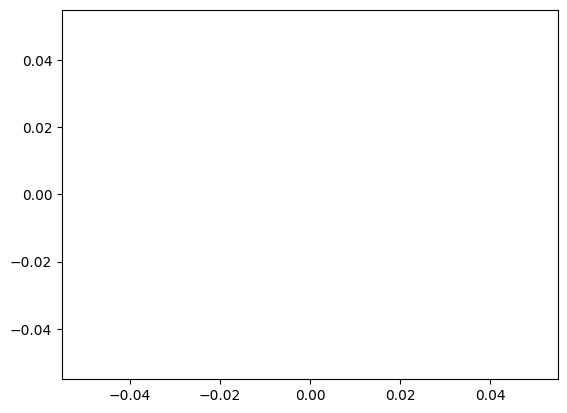

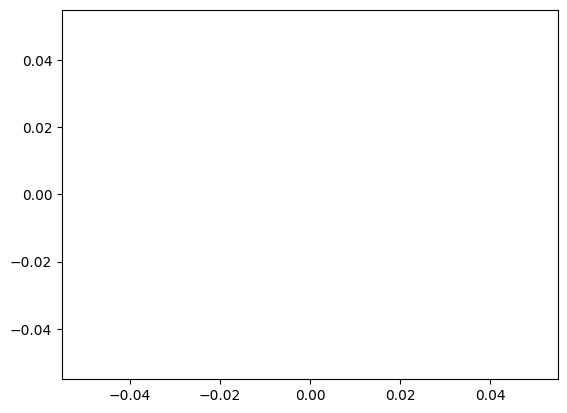

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772ffbdfdea0, execution_count=5 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772ffbdfe170, raw_cell="import matplotlib.pyplot as plt

plt.plot([i[0] fo.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W3sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given

In [5]:
import matplotlib.pyplot as plt

plt.plot([i[0] for i in data],color="blue")
plt.plot([i[2] for i in data],color="red")
plt.show()

plt.plot([i[1] for i in data],color="blue")
plt.plot([i[3] for i in data],color="red")
plt.show()


In [6]:
import copy
from jaxrl_m.networks import OriginalCritic

rng = jax.random.PRNGKey(42)

args_dict2 = copy.deepcopy(args_dict)
args_dict2["on_policy_data"]=True
agent_on = create_learner(**args_dict)
agent_off = create_learner(**args_dict2)

transitions = actor_buffer.get_all()
idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)

agent_on.actor.params['log_stds'] = -100 * jnp.ones_like(agent_on.actor.params['log_stds'])
agent_on.actor.params['means']['kernel'] = jnp.copy(agent.actor.params['means']['kernel'])
agent_on = agent_on.update_critics_seq(batches,R2)

################################################

transitions = replay_buffer.get_all()
idxs = jax.random.choice(agent.rng,a=transitions['observations'].shape[0], shape=(NUM_UPDATES,256), replace=True)
batches = jax.vmap(lambda i: jax.tree.map(lambda x: x[i], transitions))(idxs)

agent_off.actor.params['log_stds'] = -100 * jnp.ones_like(agent_off.actor.params['log_stds'])
agent_off.actor.params['means']['kernel'] = jnp.copy(agent.actor.params['means']['kernel'])
agent_off = agent_off.update_critics_seq(batches,R2)

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 772e5c17beb0, raw_cell="import copy
from jaxrl_m.networks import OriginalC.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W4sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


TypeError: _WandbInit._resume_backend() takes 1 positional argument but 2 were given

Extra kwargs: {'max_steps': 50000}
Extra kwargs: {'max_steps': 50000, 'on_policy_data': True}
Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772e5c178940, execution_count=6 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772e5c17beb0, raw_cell="import copy
from jaxrl_m.networks import OriginalC.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W4sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given

In [7]:
transitions = test_buffer.get_all()
#transitions = replay_buffer.get_all()
#transitions = jax.tree.map(lambda x:x[:10000],transitions)
params_on = {'params':agent_on.critic.params}
params_on = jax.tree.map(lambda x:x[0],params_on)
params_off = {'params':agent_off.critic.params}
params_off = jax.tree.map(lambda x:x[0],params_off)
_,tmp_on= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params_on,transitions["observations"],transitions["actions"],mutable='intermediates')
_,tmp_off= OriginalCritic(hidden_dims=(args.hidden_dims,args.hidden_dims)).apply(params_off,transitions["observations"],transitions["actions"],mutable='intermediates')

embeds_on = tmp_on['intermediates']['features'][0]
embeds_off = tmp_off['intermediates']['features'][0]

@jax.jit
def pairwise_euclidean(x, y):
  assert x.ndim == y.ndim == 2
  return jnp.sqrt(((x[:, None, :] - y[None, :, :]) ** 2).sum(-1))

dist_on = pairwise_euclidean(embeds_on.squeeze(),embeds_on.squeeze())
dist_off = pairwise_euclidean(embeds_off.squeeze(),embeds_off.squeeze())

print(dist_on.mean(),dist_off.mean())

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 772e5c1bedd0, raw_cell="transitions = test_buffer.get_all()
#transitions =.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W5sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


TypeError: _WandbInit._resume_backend() takes 1 positional argument but 2 were given

4.8967986 0.18720822
Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772e5c1bed70, execution_count=7 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772e5c1bedd0, raw_cell="transitions = test_buffer.get_all()
#transitions =.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W5sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given

In [8]:
jax.config.update('jax_default_matmul_precision', 'highest')
obs = env.reset()

K = np.array(agent.actor.params['means']['kernel'])
noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without
K_ref= compute_lqr_feedback_gain(env)

########################################
reference = compute_lqr_V(obs,env,K_ref)
V = compute_lqr_V(obs,env,-K.T)
V_noise = compute_lqr_V_gaussian_policy(obs,env,-K.T,noise)
reference_noise = compute_lqr_V_gaussian_policy(obs,env,K_ref,noise)
print(f'Reference {reference} Reference_noise {reference_noise}')

total = 0
gamma = 1
exploration_rng = jax.random.PRNGKey(52)

print(f'V {V} V_noise {V_noise}')

for i in range(500):

    exploration_rng, key = jax.random.split(exploration_rng)
    #action,_,_ = agent.sample_actions(obs,seed=exploration_rng)
    # action = agent.deterministic_action(obs)
    action = K.T@obs
    next_obs, reward, done, info = env.step(action)  
    obs = next_obs
    total+=gamma*reward
    gamma *= 0.99
    
print(total)


Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 772e546ca8f0, raw_cell="jax.config.update('jax_default_matmul_precision', .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W6sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


TypeError: _WandbInit._resume_backend() takes 1 positional argument but 2 were given

Reference [[-96.2351748]] Reference_noise [[-100.95548119]]
V [[-128.52629138]] V_noise [[-194.72947432]]
-67.1319369289838
Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772e5c2fedd0, execution_count=8 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772e546ca8f0, raw_cell="jax.config.update('jax_default_matmul_precision', .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#W6sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given

In [9]:
jax.config.update('jax_default_matmul_precision', 'highest')
obs = env.reset()

K = np.array(agent.actor.params['means']['kernel'])
noise = jnp.diag(jnp.exp(agent.actor.params['log_stds']))# For state dependant noise but i think formulation is without
K_ref= compute_lqr_feedback_gain(env)

########################################
reference = compute_lqr_V(obs,env,-K_ref)
V = compute_lqr_V(obs,env,-K.T)
V_noise = compute_lqr_V_gaussian_policy(obs,env,-K.T,noise)
reference_noise = compute_lqr_V_gaussian_policy(obs,env,-K_ref,noise)
print(f'Reference {reference} Reference_noise {reference_noise}')

total = 0
gamma = 1
exploration_rng = jax.random.PRNGKey(52)

print(f'V {V} V_noise {V_noise}')

for i in range(500):

    exploration_rng, key = jax.random.split(exploration_rng)
    #action,_,_ = agent.sample_actions(obs,seed=exploration_rng)
    action = agent.deterministic_action(obs)
    next_obs, reward, done, info = env.step(action)  
    obs = next_obs
    total+=gamma*reward
    gamma *= 0.99
    
print(total)


Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 772e546df9a0, raw_cell="jax.config.update('jax_default_matmul_precision', .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#X10sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


TypeError: _WandbInit._resume_backend() takes 1 positional argument but 2 were given

Reference [[-98.50446905]] Reference_noise [[-99.22781771]]
V [[-248.7232934]] V_noise [[-314.92647634]]
-161.23375889374483
Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x772ffa7344f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 772e546dfb20, execution_count=9 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 772e546df9a0, raw_cell="jax.config.update('jax_default_matmul_precision', .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Btesla.la1.uni-wuerzburg.de/home/mahdi/Desktop/supersac/LQR.ipynb#X10sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


TypeError: _WandbInit._pause_backend() takes 1 positional argument but 2 were given